# Notebook 01b - Spline Choreography Kinematics, Jerk-Minimised (QP)

Author: Stellars Henson<br>
Approach: model the full 3 s choreography as a **single C2-continuous trajectory** for one body - Victoria's centre of mass - with position, velocity and acceleration all smooth.  The tangential acceleration along the path is a **cubic spline**; velocity and position are its analytic antiderivatives, so the position trajectory is C4.  The spline knots are placed by **quadratic programming**: minimise the integrated jerk-squared subject to *linear* constraints.

## Model decisions

- **One body only.**  This is a kinematics study of Victoria's CoM.  Andrew's motion is not modelled here.
- **Stationary points at the direction changes.**  At the impact moment (the change of direction at the door) both velocity AND acceleration are effectively zero - the body decelerates to a momentary rest at the door, then reverses.  Likewise the choreography starts and ends at rest.  So there are three stationary points: start (t=0), impact (t=t_impact), end (t=3), each with v=0 and a=0.
- **Pull distance 2.0 m** - the curved-path arc length (corridor diagonal + the body rotation mean the CoM cannot travel a straight line).
- **Forces are computed later, not here.**  The total force at the impact will be the sum of an *impact force* (the collision / body compression) plus an *acceleration force* (Victoria pushing herself off the door and driving with her feet).  Their proportion is a kinematics hyperparameter applied downstream.  This notebook produces only the smooth kinematic trajectory; `a(t)` here is the net kinematic acceleration.

## Outputs

- `reports/figures/01b-path-curve.png` - the curved CoM path in the corridor plane
- `reports/figures/01b-trajectory-splines.png` - position / velocity / acceleration / jerk, all smooth
- `reports/figures/01b-continuity-check.png` - numerical C2 continuity verification
- `reports/figures/01b-yield-study.png` - peak impact force vs body compressive-yield model

In [1]:
# Imports
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

from scipy.interpolate import CubicSpline

%load_ext autoreload
%autoreload 2

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
SEED = 42
np.random.seed(SEED)

## Kinematics Linear Prototype

Before the smooth spline trajectory, the problem is grounded with the **kinematics linear prototype** - a piecewise-linear acceleration model, the idealised skeleton that the later spline smoothing, integration and QP optimisation refine.  In this reference model the acceleration is a sequence of straight-line ramps and plateaus; integrating once gives a piecewise-quadratic velocity and again a piecewise-cubic position.  The diagram below shows all three.  It is **symbolic** - the impact spike `a_imp` is physically about ten times deeper than `a_max`, so it is drawn off-scale on the acceleration panel to keep the choreography levels visible.  The segment areas are balanced, so velocity returns to zero at all three stationary points (start, impact, end).

**Phase 1** (pull to the door):

1. **Start jerk / give** - acceleration ramps linearly from `a = 0` up to `a_max`
2. **Constant acceleration** - plateau at `a_max`
3. **Release** - acceleration ramps `a_max -> 0` over its yield time
4. **Coast** - `a = 0`, the body travels at constant speed
5. **Impact** - a deceleration spike `0 -> a_imp -> 0`, ending exactly when `v = 0` (the stationary point at the door)

**Phase 2** (return from the door):

1. **Reverse jerk** - acceleration ramps from `(a = 0, v = 0)` to the reverse-direction acceleration `a_rev`
2. **Deceleration** - acceleration ramps from `a_rev` through zero to the brake level `a_brk`, then back to `0`, bringing the body to rest (`a = 0, v = 0`)

The ramp corners in this model are sharp - infinite jerk at every breakpoint.  The spline model below replaces each corner with a C2-smooth transition, and the QP places the knots to minimise jerk.  The linear model is the reference the smoothed trajectory is measured against.

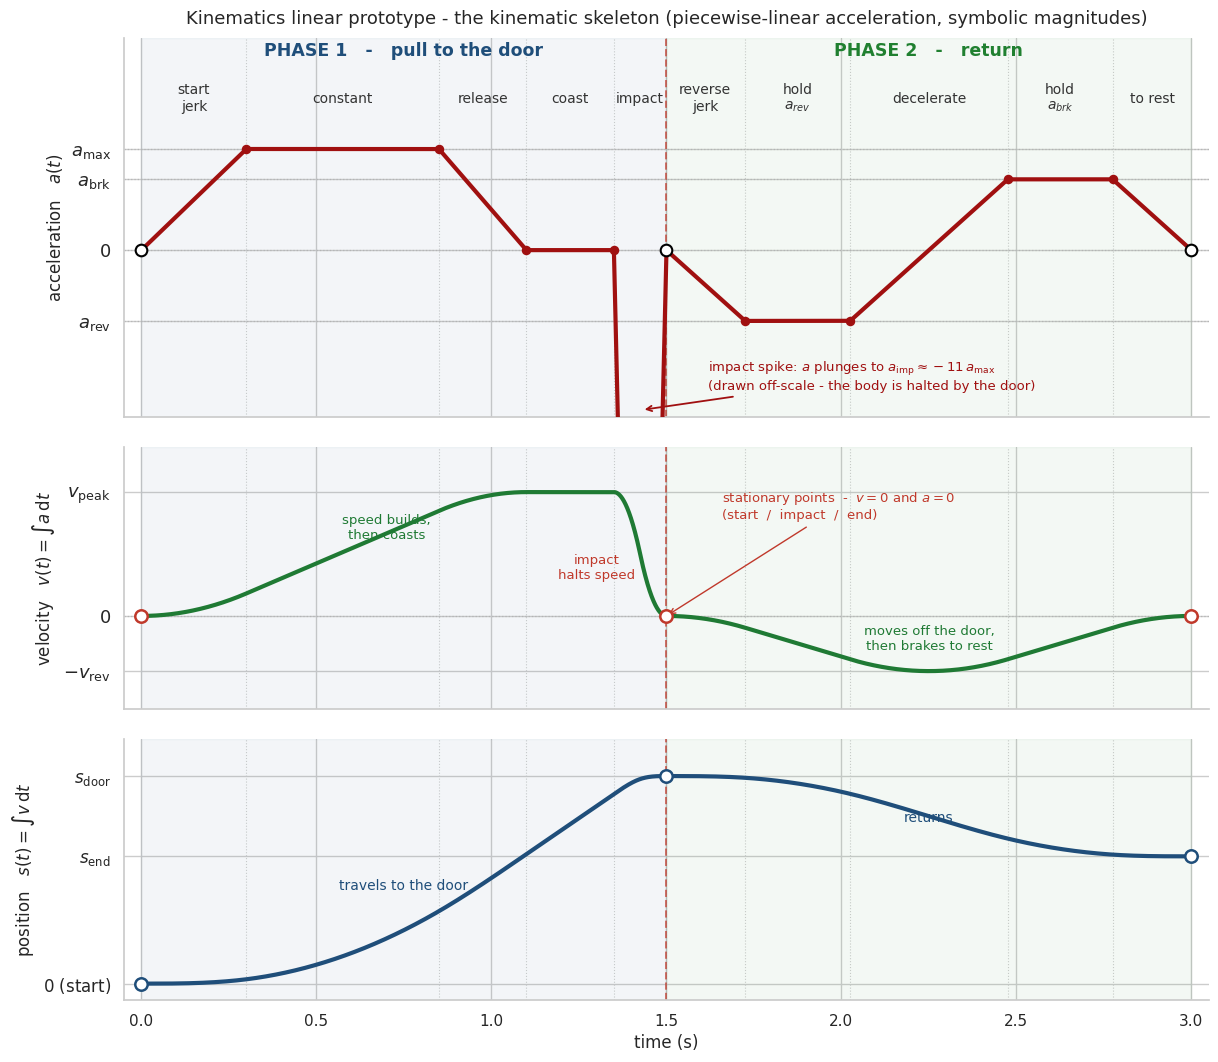

Linear reference model: acceleration (piecewise-linear) integrates to velocity (piecewise-quadratic) and to position (piecewise-cubic). Vertical guides link the same instant across all three panels. Areas balanced so v=0 at the three stationary points. The sharp corners are infinite-jerk - the spline QP below smooths them to C2.


In [3]:
# Linear reference model - piecewise-linear acceleration, SYMBOLIC schematic.
# Areas balanced so velocity returns to zero at every stationary point
# (start, impact, end). Acceleration integrates once to velocity, again to
# position. The impact spike a_imp is ~11x deeper than a_max and is drawn
# off-scale so the choreography levels stay legible. Structure only.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path as _Path
_FIG_DIR = _Path("..") / "reports" / "figures"
_FIG_DIR.mkdir(parents=True, exist_ok=True)

# symbolic acceleration levels (illustrative magnitudes)
a_max = 1.00                     # phase-1 peak choreography acceleration
a_rev = -0.70                    # phase-2 reverse-direction acceleration
a_brk = -a_rev                   # phase-2 brake (mirrors a_rev -> phase-2 v balances)

# piecewise-linear acceleration breakpoints (time, accel)
bp_t = [0.00, 0.30, 0.85, 1.10, 1.35, 1.425, 1.50,
        1.725, 2.025, 2.475, 2.775, 3.00]
A_accel = 0.5 * 0.30 * a_max + 0.55 * a_max + 0.5 * 0.25 * a_max
a_imp = -A_accel / (0.5 * 0.15)   # impact depth that cancels the phase-1 accel area
bp_a = [0.0, a_max, a_max, 0.0, 0.0, a_imp, 0.0,
        a_rev, a_rev, a_brk, a_brk, 0.0]

# integrate: a -> v -> s
tg = np.linspace(0, 3.0, 6000)
a_lin = np.interp(tg, bp_t, bp_a)
v_lin = np.concatenate([[0], np.cumsum((a_lin[1:] + a_lin[:-1]) / 2 * np.diff(tg))])
s_lin = np.concatenate([[0], np.cumsum((v_lin[1:] + v_lin[:-1]) / 2 * np.diff(tg))])
t_imp = 1.5
v_imp, s_imp = np.interp(t_imp, tg, v_lin), np.interp(t_imp, tg, s_lin)
v_peak, v_min, s_end = v_lin.max(), v_lin.min(), s_lin[-1]

# segment dividers + labels
seg_bounds = [0.30, 0.85, 1.10, 1.35, 1.50, 1.725, 2.025, 2.475, 2.775]
segments = [(0.15, "start\njerk"), (0.575, "constant"), (0.975, "release"),
            (1.225, "coast"), (1.425, "impact"), (1.61, "reverse\njerk"),
            (1.875, "hold\n$a_{rev}$"), (2.25, "decelerate"),
            (2.625, "hold\n$a_{brk}$"), (2.89, "to rest")]

fig = plt.figure(figsize=(14, 12.5))
gs = GridSpec(3, 1, height_ratios=[1.45, 1.0, 1.0], hspace=0.10)
ax_a = fig.add_subplot(gs[0])
ax_v = fig.add_subplot(gs[1], sharex=ax_a)
ax_s = fig.add_subplot(gs[2], sharex=ax_a)

# shared backdrop: phase tints + segment dividers + impact line
for ax in (ax_a, ax_v, ax_s):
    ax.axvspan(0.0, 1.5, color="#1f4e7a", alpha=0.05)
    ax.axvspan(1.5, 3.0, color="#208030", alpha=0.05)
    for xb in seg_bounds:
        ax.axvline(xb, color="#cfcfcf", ls=":", lw=0.8, zorder=0)
    ax.axvline(1.5, color="#c0392b", ls="--", lw=1.4, alpha=0.7, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(-0.05, 3.05)

# ----- ACCELERATION -----
for lvl in (a_max, a_brk, 0.0, a_rev):
    ax_a.axhline(lvl, color="#b0b0b0", ls=":", lw=0.9, alpha=0.8)
ax_a.plot(tg, a_lin, color="#a01010", lw=3.0, solid_joinstyle="round", zorder=4)
ax_a.scatter(bp_t, bp_a, color="#a01010", s=34, zorder=5)   # knots
ax_a.scatter([0, 1.5, 3.0], [0, 0, 0], facecolor="white", edgecolor="black",
             s=70, lw=1.5, zorder=6)
ax_a.set_yticks([a_rev, 0.0, a_brk, a_max])
ax_a.set_yticklabels([r"$a_\mathrm{rev}$", "$0$", r"$a_\mathrm{brk}$",
                      r"$a_\mathrm{max}$"], fontsize=13)
ax_a.set_ylim(a_rev - 0.95, a_max * 2.10)
ax_a.set_ylabel("acceleration   $a(t)$", fontsize=12)
# segment labels in a band above the curve
for tx, lab in segments:
    ax_a.text(tx, a_max * 1.50, lab, ha="center", va="center", fontsize=10,
              color="#333333")
# phase headers
ax_a.text(0.75, a_max * 1.92, "PHASE 1   -   pull to the door", ha="center",
          fontsize=12.5, fontweight="bold", color="#1f4e7a")
ax_a.text(2.25, a_max * 1.92, "PHASE 2   -   return", ha="center",
          fontsize=12.5, fontweight="bold", color="#208030")
# impact off-scale callout
ax_a.annotate(r"impact spike: $a$ plunges to $a_\mathrm{imp}\approx-11\,a_\mathrm{max}$"
              "\n(drawn off-scale - the body is halted by the door)",
              xy=(1.43, a_rev - 0.88), xytext=(1.62, a_rev - 0.55),
              fontsize=9.5, color="#a01010", va="center",
              arrowprops=dict(arrowstyle="->", color="#a01010", lw=1.3))
ax_a.set_title("Kinematics linear prototype - the kinematic skeleton "
               "(piecewise-linear acceleration, symbolic magnitudes)",
               fontsize=13, pad=10)

# ----- VELOCITY -----
ax_v.axhline(0.0, color="#b0b0b0", ls=":", lw=0.9, alpha=0.8)
ax_v.plot(tg, v_lin, color="#1f7a34", lw=3.0, zorder=4)
ax_v.scatter([0, t_imp, 3.0], [0, v_imp, 0], facecolor="white",
             edgecolor="#c0392b", s=80, lw=1.8, zorder=6)
ax_v.set_yticks([v_min, 0.0, v_peak])
ax_v.set_yticklabels([r"$-v_\mathrm{rev}$", "$0$", r"$v_\mathrm{peak}$"],
                     fontsize=13)
ax_v.set_ylabel(r"velocity   $v(t)=\int a\,\mathrm{d}t$", fontsize=12)
ax_v.set_ylim(v_min - 0.25, v_peak + 0.30)
ax_v.text(0.70, v_peak * 0.62, "speed builds,\nthen coasts", ha="center",
          fontsize=9.5, color="#1f7a34")
ax_v.text(1.30, v_peak * 0.30, "impact\nhalts speed", ha="center", fontsize=9.5,
          color="#c0392b")
ax_v.text(2.25, v_min * 0.62, "moves off the door,\nthen brakes to rest",
          ha="center", fontsize=9.5, color="#1f7a34")
ax_v.annotate("stationary points  -  $v=0$ and $a=0$\n(start  /  impact  /  end)",
              xy=(t_imp, v_imp), xytext=(1.66, v_peak * 0.78), fontsize=9.5,
              color="#c0392b", arrowprops=dict(arrowstyle="->", color="#c0392b"))

# ----- POSITION -----
ax_s.plot(tg, s_lin, color="#1f4e7a", lw=3.0, zorder=4)
ax_s.scatter([0, t_imp, 3.0], [0, s_imp, s_end], facecolor="white",
             edgecolor="#1f4e7a", s=80, lw=1.8, zorder=6)
ax_s.set_yticks([0.0, s_end, s_imp])
ax_s.set_yticklabels(["$0$ (start)", r"$s_\mathrm{end}$", r"$s_\mathrm{door}$"],
                     fontsize=12)
ax_s.set_ylabel(r"position   $s(t)=\int v\,\mathrm{d}t$", fontsize=12)
ax_s.set_ylim(-0.08 * s_imp, s_imp * 1.18)
ax_s.set_xlabel("time (s)", fontsize=12)
ax_s.text(0.75, s_imp * 0.45, "travels to the door", ha="center", fontsize=10,
          color="#1f4e7a")
ax_s.text(2.25, s_imp * 0.78, "returns", ha="center", fontsize=10,
          color="#1f4e7a")

for ax in (ax_a, ax_v):
    plt.setp(ax.get_xticklabels(), visible=False)

fig.savefig(_FIG_DIR / "01b-linear-reference-model.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Linear reference model: acceleration (piecewise-linear) integrates to "
      "velocity (piecewise-quadratic) and to position (piecewise-cubic). "
      "Vertical guides link the same instant across all three panels. Areas "
      "balanced so v=0 at the three stationary points. The sharp corners are "
      "infinite-jerk - the spline QP below smooths them to C2.")

## Configuration - KINEMATICS

Single source of truth.  The yield-time block characterises the smooth transitions; the body-compression block feeds the downstream force calculation, not the trajectory itself.

In [4]:
KINEMATICS = {
    "total_time_s": 3.0,
    "time": {
        # Phase-1 (pull) duration is a CHOSEN hyperparameter, not
        # optimiser-picked: the choreography duration is a claim about
        # the event. Velocity is then forced by the distance/time
        # coupling: peak velocity ~ 2 * arc_length / phase1_duration.
        "phase1_duration_s": 1.5,
    },
    "phase1_pull": {
        "path_arc_length_m": 2.0,     # curved-path arc length, corridor door-to-door
        "lateral_offset_m": 0.25,     # diagonal sag of the curved CoM path
        "rotation_rad": math.pi,      # 180 deg half-rotation
    },
    "phase2_return": {
        "translation_m": 0.50,        # 50 cm back from the door
        "rotation_rad": math.pi,      # another 180 deg
    },
    "bodies": {
        "victoria_mass_kg": 70.0,
        "victoria_yaw_inertia_kgm2": 1.4,
    },
    "stationary_points": {
        # At each, both velocity and acceleration are zero.
        "start":  {"t": 0.0,  "s": 0.0},
        "impact": {"t": None, "s": 2.0},   # t optimised; s = arc length to door
        "end":    {"t": 3.0,  "s": 1.5},   # 2.0 - 0.5 m back
    },
    "force_model": {
        # Applied DOWNSTREAM (not in this notebook). Total force at impact =
        # impact_force + acceleration_force. accel_fraction is the share that
        # is Victoria's own propulsion (push off door + feet) vs the passive
        # collision. Kinematics hyperparameter, swept later.
        "accel_force_fraction": 0.5,
    },
    "impact": {
        "door": "rigid",
        "body_compression_m": 0.030,  # rigid door => all 3 cm is body compression
        "body_stiffness_N_per_m": 8.0e5,
    },
    # NOTE on yield times: the acceleration ramps (start ramp-up, the
    # decel into the door, the final ramp-down to rest) are NOT pinned.
    # Pinning the spline to a prescribed ramp fights jerk-minimisation
    # and injects spurious extra acceleration lobes. The jerk-minimal
    # QP already produces a naturally gentle start ramp (clamped spline:
    # a(0)=0, a'(0)=0). The emergent ramp durations are measured and
    # reported below as derived quantities, not chosen as inputs.
    "spline": {
        "n_knots": 41,
        "n_eval": 6000,
    },
    "paths": {"fig_dir": Path("..") / "reports" / "figures"},
}

FIG_DIR = KINEMATICS["paths"]["fig_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

tbl = Table(show_header=False, box=None, padding=(0, 2))
tbl.add_column("k", style="bold cyan"); tbl.add_column("v")
for section, items in KINEMATICS.items():
    if isinstance(items, dict):
        tbl.add_row(f"[bold magenta]{section}[/bold magenta]", "")
        for k, v in items.items():
            tbl.add_row(f"  {k}", f"[white]{v}[/white]")
    else:
        tbl.add_row(f"[bold magenta]{section}[/bold magenta]", f"[white]{items}[/white]")
console.print(Panel(tbl, title="[bold green]KINEMATICS[/bold green]", border_style="green"))

╭────────────────────────────────────────────────── KINEMATICS ───────────────────────────────────────────────────╮
│   total_time_s                   3.0                                                                            │
│   time                                                                                                          │
│     phase1_duration_s            1.5                                                                            │
│   phase1_pull                                                                                                   │
│     path_arc_length_m            2.0                                                                            │
│     lateral_offset_m             0.25                                                                           │
│     rotation_rad                 3.141592653589793                                                              │
│   phase2_return                                                                                                 │
│     translation_m                0.5                                                                            │
│     rotation_rad                 3.141592653589793                                                              │
│   bodies                                                                                                        │
│     victoria_mass_kg             70.0                                                                           │
│     victoria_yaw_inertia_kgm2    1.4                                                                            │
│   stationary_points                                                                                             │
│     start                        {'t': 0.0, 's': 0.0}                                                           │
│     impact                       {'t': None, 's': 2.0}                                                          │
│     end                          {'t': 3.0, 's': 1.5}                                                           │
│   force_model                                                                                                   │
│     accel_force_fraction         0.5                                                                            │
│   impact                                                                                                        │
│     door                         rigid                                                                          │
│     body_compression_m           0.03                                                                           │
│     body_stiffness_N_per_m       800000.0                                                                       │
│   spline                                                                                                        │
│     n_knots                      41                                                                             │
│     n_eval                       6000                                                                           │
│   paths                                                                                                         │
│     fig_dir                      ../reports/figures                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Curved CoM Path

Victoria's centre of mass does not travel a straight line - the corridor geometry has a diagonal offset and a body rotating 180 deg sweeps its CoM along a curve.  We model the path as a smooth 2D curve (quadratic Bezier) with **arc length 2.0 m** - the distance the CoM actually travels.

Curved path arc length: 2.000 m  (straight-line 1.919 m)

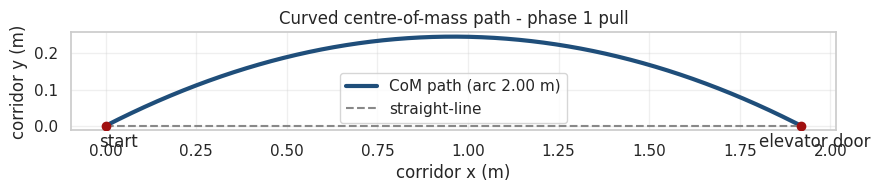

In [5]:
p1 = KINEMATICS["phase1_pull"]
L_arc = p1["path_arc_length_m"]
sag = p1["lateral_offset_m"]

P0 = np.array([0.0, 0.0])
P1 = np.array([1.95, 0.0])
Pc = np.array([0.975, 2.0 * sag])

u = np.linspace(0, 1, 4000)
bez = (1-u)[:, None]**2 * P0 + 2*(1-u)[:, None]*u[:, None] * Pc + u[:, None]**2 * P1
seg = np.sqrt(np.sum(np.diff(bez, axis=0)**2, axis=1))
arc = np.concatenate([[0], np.cumsum(seg)])
scale = L_arc / arc[-1]
bez *= scale
arc *= scale

console.print(f"Curved path arc length: {arc[-1]:.3f} m  "
              f"(straight-line {np.linalg.norm(P1-P0)*scale:.3f} m)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bez[:, 0], bez[:, 1], color="#1f4e7a", lw=3, label=f"CoM path (arc {arc[-1]:.2f} m)")
ax.plot([P0[0]*scale, P1[0]*scale], [0, 0], "--", color="#888", label="straight-line")
ax.scatter([P0[0]*scale, P1[0]*scale], [0, 0], color="#a01010", zorder=5)
ax.annotate("start", P0*scale, textcoords="offset points", xytext=(-5, -15))
ax.annotate("elevator door", P1*scale, textcoords="offset points", xytext=(-30, -15))
ax.set_aspect("equal")
ax.set_xlabel("corridor x (m)"); ax.set_ylabel("corridor y (m)")
ax.set_title("Curved centre-of-mass path - phase 1 pull")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-path-curve.png", dpi=140, bbox_inches="tight")
plt.show()

## Jerk-Minimising QP Trajectory Solver

The tangential acceleration $a(t)$ is a cubic spline through $N$ knots.  Velocity $v=\int a$ and position $s=\int v$ are its analytic antiderivatives, so $s(t)$ is C4.  Because the spline is linear in its knot values $\mathbf a$, every kinematic functional ($v$, $s$ at any time) is **linear** in $\mathbf a$ and the smoothness cost $\int\dot a^2\,dt$ is a **quadratic form** $\tfrac12\mathbf a^\top H\mathbf a$.

So the trajectory solves the equality-constrained **quadratic program**

$$\min_{\mathbf a}\ \tfrac12\mathbf a^\top H\mathbf a \quad\text{s.t.}\quad C\mathbf a=\mathbf d$$

via the KKT linear system - one solve, no iteration.

**Constraints (9 total)** - the three stationary points each contribute s, v, a:

| Point | s | v | a |
|---|---|---|---|
| start (t=0) | 0 | 0 | 0 |
| impact (t=t_imp) | 2.0 m | 0 | 0 |
| end (t=3) | 1.5 m | 0 | 0 |

In [6]:
T = KINEMATICS["total_time_s"]
N = KINEMATICS["spline"]["n_knots"]
n_eval = KINEMATICS["spline"]["n_eval"]
t_knots = np.linspace(0.0, T, N)
t_eval = np.linspace(0.0, T, n_eval)
dt_eval = t_eval[1] - t_eval[0]

def smootherstep(s):
    """6s^5-15s^4+10s^3, clipped [0,1]. Zero 1st+2nd deriv at ends."""
    s = np.clip(s, 0.0, 1.0)
    return s * s * s * (s * (s * 6.0 - 15.0) + 10.0)

def accel_spline(a_knots):
    """Cubic spline a(t) through the knots, clamped (a'=0) at both ends."""
    return CubicSpline(t_knots, a_knots, bc_type=((1, 0.0), (1, 0.0)))

def kinematics_from_knots(a_knots):
    """Acceleration spline integrated twice. v(0)=s(0)=0."""
    cs_a = accel_spline(a_knots)
    cs_v = cs_a.antiderivative()
    cs_s = cs_v.antiderivative()
    a = cs_a(t_eval)
    v = cs_v(t_eval) - cs_v(0.0)
    s = cs_s(t_eval) - cs_s(0.0) - cs_v(0.0) * t_eval
    jerk = cs_a(t_eval, 1)
    return {"t": t_eval, "a": a, "v": v, "s": s, "jerk": jerk}

def v_at(a_knots, t):
    cs_a = accel_spline(a_knots); cs_v = cs_a.antiderivative()
    return float(cs_v(t) - cs_v(0.0))

def s_at(a_knots, t):
    cs_a = accel_spline(a_knots); cs_v = cs_a.antiderivative()
    cs_s = cs_v.antiderivative()
    return float(cs_s(t) - cs_s(0.0) - cs_v(0.0) * t)

def a_at(a_knots, t):
    return float(accel_spline(a_knots)(t))

def linear_row(func):
    """Coefficient row r with func(a_knots) = r . a_knots (func is linear)."""
    row = np.zeros(N)
    for i in range(N):
        e = np.zeros(N); e[i] = 1.0
        row[i] = func(e)
    return row

# Jerk-squared quadratic form H (probe unit-knot jerk responses)
jerk_basis = np.zeros((N, n_eval))
for i in range(N):
    e = np.zeros(N); e[i] = 1.0
    jerk_basis[i] = accel_spline(e)(t_eval, 1)
H = (jerk_basis @ jerk_basis.T) * dt_eval + 1e-9 * np.eye(N)
console.print(f"Spline QP ready: {N} knots, jerk form H is {H.shape}")

Spline QP ready: 41 knots, jerk form H is (41, 41)

In [7]:
def solve_qp(t_impact):
    """Pure jerk-minimising QP - 9 equality constraints, no yield pinning.
    s, v, a = (0,0,0) start; (L_arc,0,0) impact; (s_end,0,0) end.
    The jerk-minimal solution is the smoothest trajectory satisfying the three
    stationary points; its acceleration has exactly 4 lobes (accelerate +
    decelerate per phase) - the irreducible physical minimum."""
    rows, rhs = [], []
    e0 = np.zeros(N); e0[0] = 1.0; rows.append(e0); rhs.append(0.0)
    rows.append(linear_row(lambda a: s_at(a, t_impact))); rhs.append(L_arc)
    rows.append(linear_row(lambda a: v_at(a, t_impact))); rhs.append(0.0)
    rows.append(linear_row(lambda a: a_at(a, t_impact))); rhs.append(0.0)
    s_end = L_arc - KINEMATICS["phase2_return"]["translation_m"]
    rows.append(linear_row(lambda a: s_at(a, T))); rhs.append(s_end)
    rows.append(linear_row(lambda a: v_at(a, T))); rhs.append(0.0)
    eT = np.zeros(N); eT[-1] = 1.0; rows.append(eT); rhs.append(0.0)
    C = np.array(rows); d = np.array(rhs)
    n_c = C.shape[0]
    KKT = np.block([[H, C.T], [C, np.zeros((n_c, n_c))]])
    sol = np.linalg.solve(KKT, np.concatenate([np.zeros(N), d]))
    return sol[:N]


# Impact time = chosen phase-1 duration hyperparameter (NOT optimised).
t_impact_opt = float(KINEMATICS["time"]["phase1_duration_s"])
KINEMATICS["stationary_points"]["impact"]["t"] = t_impact_opt
a_knots_opt = solve_qp(t_impact_opt)
traj = kinematics_from_knots(a_knots_opt)
traj["t_impact"] = t_impact_opt

# Emergent yield ramps: time for |a| to rise from 0 to 90% of the phase-1
# acceleration peak (start ramp), and to fall back over the final stop.
_t = traj["t"]; _a = np.abs(traj["a"])
_ph1 = _t <= t_impact_opt
_pk1 = _a[_ph1].max()
_start_ramp = float(_t[_ph1][np.argmax(_a[_ph1] >= 0.9 * _pk1)])
_ph2 = _t >= t_impact_opt
_pk2 = _a[_ph2].max()
# stop ramp: time from last 90%-of-peak crossing to T
_idx2 = np.where(_a[_ph2] >= 0.9 * _pk2)[0]
_stop_ramp = float(T - _t[_ph2][_idx2[-1]]) if _idx2.size else 0.0

console.print(f"[bold green]Phase-1 duration (hyperparameter):[/bold green] {t_impact_opt:.3f} s")
console.print(f"  phase-2 duration  = {T - t_impact_opt:.3f} s")
console.print(f"  peak acceleration = {np.abs(traj['a']).max():.3f} m/s^2")
console.print(f"  peak jerk         = {np.abs(traj['jerk']).max():.2f} m/s^3")
console.print(f"  peak velocity     = {np.abs(traj['v']).max():.3f} m/s")
console.print(f"  v, a at impact    = {v_at(a_knots_opt, t_impact_opt):.2e} m/s, "
              f"{a_at(a_knots_opt, t_impact_opt):.2e} m/s^2  (stationary point)")
console.print(f"  emergent start ramp = {_start_ramp*1000:.0f} ms, "
              f"stop ramp = {_stop_ramp*1000:.0f} ms  (jerk-minimal, not pinned)")

Phase-1 duration (hyperparameter): 1.500 s

phase-2 duration  = 1.500 s

peak acceleration = 5.264 m/s^2

peak jerk         = 37.76 m/s^3

peak velocity     = 2.533 m/s

v, a at impact    = 1.72e-15 m/s, 4.33e-15 m/s^2  (stationary point)

emergent start ramp = 218 ms, stop ramp = 216 ms  (jerk-minimal, not pinned)

## Trajectory - position, velocity, acceleration, jerk

All four curves are smooth.  The impact at $t_\text{impact}$ is a **stationary point**: velocity and acceleration both pass through zero - the body decelerates to momentary rest at the door, then reverses.

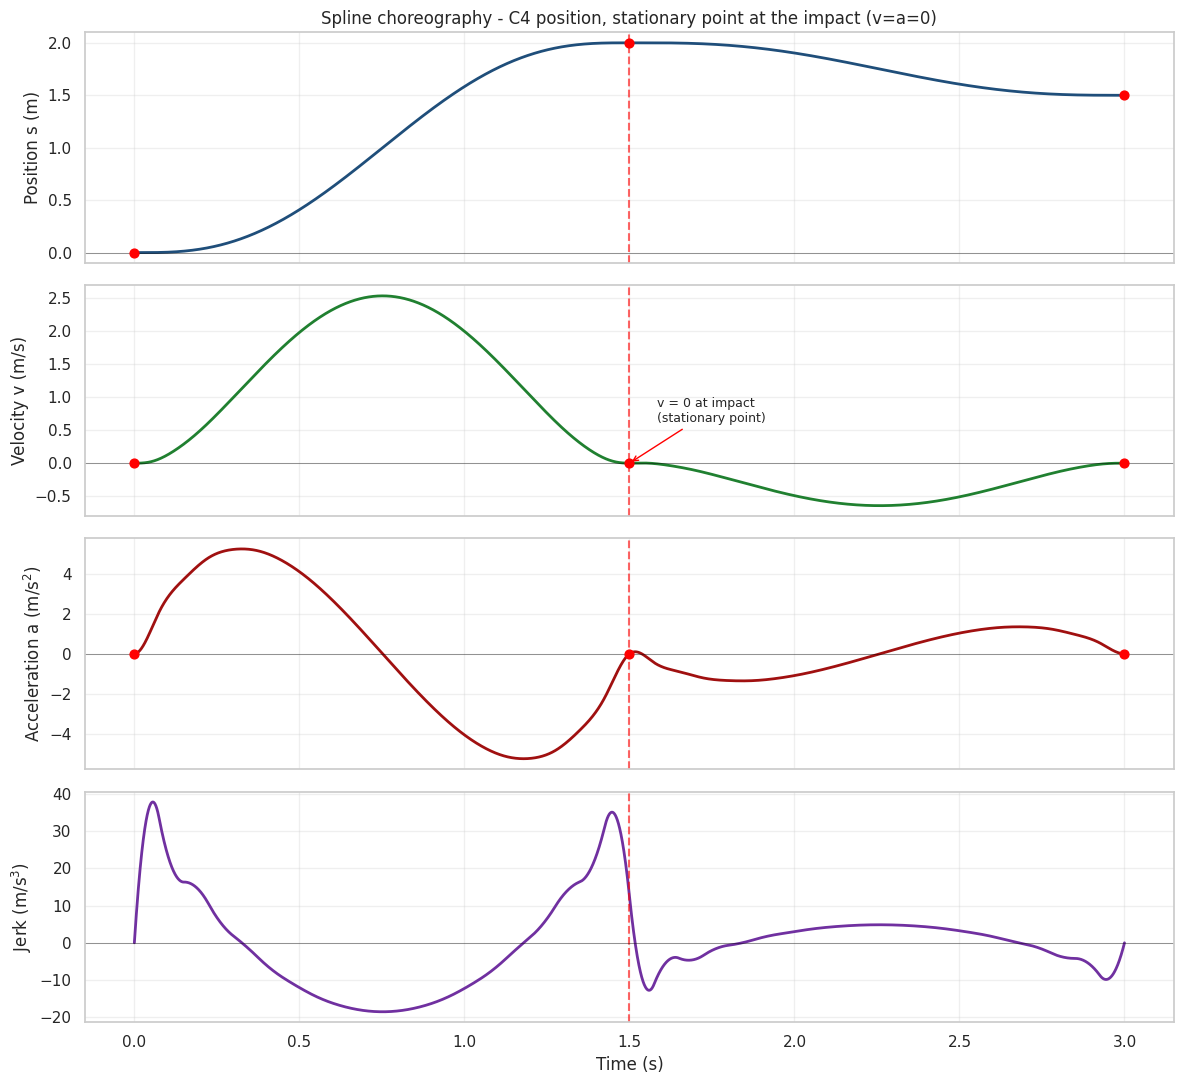

                     Optimised spline choreography                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Quantity                      ┃                               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Impact time (door reached)    │                             1.500 s │
│ Phase 1 (pull) duration       │                             1.500 s │
│ Phase 2 (return) duration     │                             1.500 s │
│ Pull arc length               │                             2.000 m │
│ Peak acceleration             │                         5.264 m/s^2 │
│ Peak jerk                     │                         37.76 m/s^3 │
│ Max speed reached             │                           2.533 m/s │
│ Acceleration peaks (>3% peak) │ 4 (expect 4: accel+decel per phase) │
└───────────────────────────────┴─────────────────────────────────────┘

In [8]:
t = traj["t"]; ti = traj["t_impact"]
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
specs = [
    ("s", "Position s (m)", "#1f4e7a"),
    ("v", "Velocity v (m/s)", "#208030"),
    ("a", "Acceleration a (m/s$^2$)", "#a01010"),
    ("jerk", "Jerk (m/s$^3$)", "#7030a0"),
]
for ax, (key, ylab, col) in zip(axes, specs):
    ax.plot(t, traj[key], color=col, lw=2)
    ax.axvline(ti, color="red", ls="--", alpha=0.6)
    ax.axhline(0, color="black", lw=0.7, alpha=0.4)
    ax.set_ylabel(ylab); ax.grid(True, alpha=0.3)
axes[0].set_title("Spline choreography - C4 position, stationary point at the impact (v=a=0)")
axes[0].scatter([0, ti, T], [0, L_arc, L_arc-0.5], color="red", zorder=5, s=40)
axes[1].scatter([0, ti, T], [0, 0, 0], color="red", zorder=5, s=40)
axes[2].scatter([0, ti, T], [0, 0, 0], color="red", zorder=5, s=40)
axes[1].annotate("v = 0 at impact\n(stationary point)", xy=(ti, 0),
                 textcoords="offset points", xytext=(20, 30),
                 arrowprops=dict(arrowstyle="->", color="red"), fontsize=9)
axes[3].set_xlabel("Time (s)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-trajectory-splines.png", dpi=140, bbox_inches="tight")
plt.show()

summary = Table(title="[bold]Optimised spline choreography[/bold]",
                show_header=True, header_style="bold cyan")
summary.add_column("Quantity"); summary.add_column("Value", justify="right")
summary.add_row("Impact time (door reached)", f"{ti:.3f} s")
summary.add_row("Phase 1 (pull) duration", f"{ti:.3f} s")
summary.add_row("Phase 2 (return) duration", f"{T-ti:.3f} s")
summary.add_row("Pull arc length", f"{traj['s'][np.argmin(np.abs(t-ti))]:.3f} m")
summary.add_row("Peak acceleration", f"[bold green]{np.abs(traj['a']).max():.3f} m/s^2[/bold green]")
summary.add_row("Peak jerk", f"{np.abs(traj['jerk']).max():.2f} m/s^3")
summary.add_row("Max speed reached", f"{np.abs(traj['v']).max():.3f} m/s")
# count significant acceleration extrema (threshold 3% of peak, so
# numerical ripple is not miscounted as a lobe)
from scipy.signal import argrelextrema as _arx
_aa = traj["a"]; _thr = 0.03 * np.abs(_aa).max()
_ext = sorted(list(_arx(_aa, np.greater)[0]) + list(_arx(_aa, np.less)[0]))
_sig_ext = [k for k in _ext if abs(_aa[k]) > _thr]
summary.add_row("Acceleration peaks (>3% peak)",
                f"{len(_sig_ext)} (expect 4: accel+decel per phase)")
console.print(summary)

## C2 Continuity Verification

Position is C4 by construction (cubic-spline acceleration integrated twice).  We verify numerically that position, velocity and acceleration have no jumps - the maximum step between adjacent samples stays at smooth-gradient level, never spiking.

                   C2 continuity check                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Quantity     ┃ Max |step| ┃ Smooth bound ┃ Status     ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ position     │  1.267e-03 │    1.358e-02 │ continuous │
│ velocity     │  2.632e-03 │    3.297e-02 │ continuous │
│ acceleration │  1.888e-02 │    1.207e-01 │ continuous │
│ jerk         │  6.718e-01 │    8.200e-01 │ continuous │
└──────────────┴────────────┴──────────────┴────────────┘

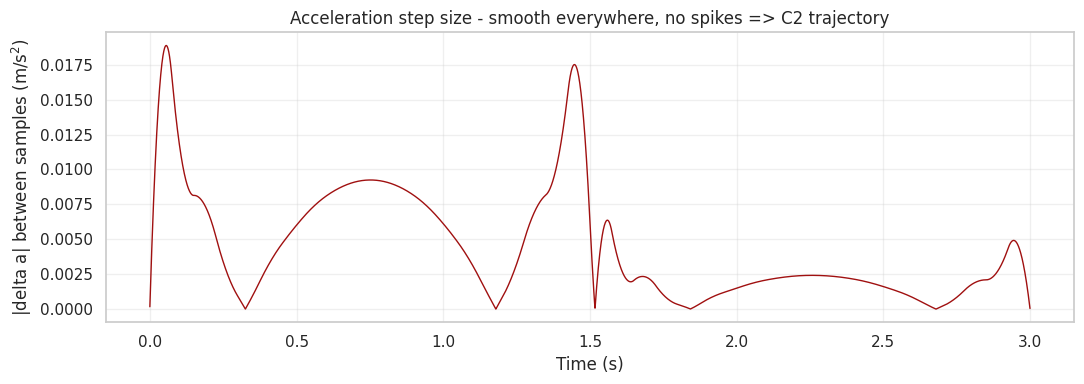

In [9]:
checks = Table(title="[bold]C2 continuity check[/bold]", show_header=True,
               header_style="bold cyan")
checks.add_column("Quantity"); checks.add_column("Max |step|", justify="right")
checks.add_column("Smooth bound", justify="right"); checks.add_column("Status")
for key, label in [("s", "position"), ("v", "velocity"),
                   ("a", "acceleration"), ("jerk", "jerk")]:
    step = np.abs(np.diff(traj[key]))
    bound = max(np.median(step) * 50.0, 1e-9)
    mx = step.max()
    checks.add_row(label, f"{mx:.3e}", f"{bound:.3e}",
                   "[green]continuous[/]" if mx < bound else "[red]JUMP[/]")
console.print(checks)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t[:-1], np.abs(np.diff(traj["a"])), color="#a01010", lw=1)
ax.set_xlabel("Time (s)"); ax.set_ylabel("|delta a| between samples (m/s$^2$)")
ax.set_title("Acceleration step size - smooth everywhere, no spikes => C2 trajectory")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-continuity-check.png", dpi=140, bbox_inches="tight")
plt.show()

## Body Compressive Yield Study

The kinematic trajectory gives the net motion.  The **impact force** is computed downstream from the body's compressive yield: at the stationary point the body has slowed to rest over its own compression distance `d`, and the deceleration-vs-distance shape depends on the yield model.  Constant deceleration (`F=m v^2/2d`) is the lowest-peak case; realistic elastic / Hertzian bodies peak higher.  The total force will be this impact force plus Victoria's own acceleration force (push off door + feet) - their split is the `accel_force_fraction` hyperparameter.

Here we tabulate the impact-force component across yield models, using the kinematic speed reached just before the stationary point as the effective closing speed.

Effective closing speed (peak phase-1 speed): 2.533 m/s

     Impact-force component, body compression 3 cm, v_close=2.53 m/s     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Yield model              ┃ a_peak (m/s2) ┃ a_peak (g) ┃ F_impact (kN) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ constant (rigid-plastic) │           107 │       10.9 │          7.49 │
│ half-sine                │           168 │       17.1 │         11.76 │
│ smootherstep             │           201 │       20.5 │         14.08 │
│ linear elastic spring    │           214 │       21.8 │         14.98 │
│ Hertzian (n=1.5)         │           267 │       27.3 │         18.72 │
└──────────────────────────┴───────────────┴────────────┴───────────────┘

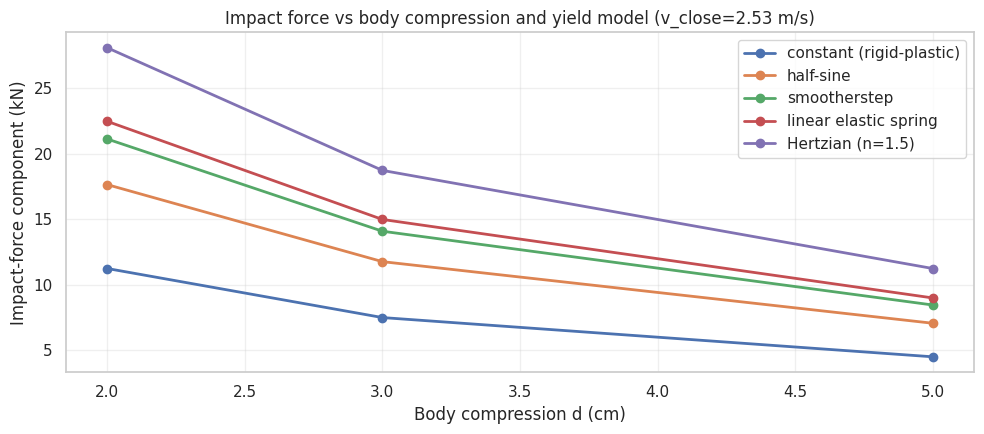

In [10]:
m_v = KINEMATICS["bodies"]["victoria_mass_kg"]
# effective closing speed: peak speed during phase 1 (the body's momentum just
# before it is brought to the stationary point at the door)
i_imp = int(np.argmin(np.abs(t - ti)))
v_close = float(np.abs(traj["v"][:i_imp]).max())
console.print(f"Effective closing speed (peak phase-1 speed): {v_close:.3f} m/s")

yield_factor = {"constant (rigid-plastic)": 0.50, "half-sine": 0.785,
                "smootherstep": 0.94, "linear elastic spring": 1.00,
                "Hertzian (n=1.5)": 1.25}
rows = []
for model, fac in yield_factor.items():
    for d_cm in [2.0, 3.0, 5.0]:
        d = d_cm / 100.0
        a_pk = fac * v_close**2 / d
        rows.append((model, d_cm, a_pk, a_pk/9.80665, m_v*a_pk/1000))
ydf = pd.DataFrame(rows, columns=["model", "d_cm", "a_peak", "a_peak_g", "F_kN"])

ytab = Table(title=f"[bold]Impact-force component, body compression 3 cm, "
             f"v_close={v_close:.2f} m/s[/bold]",
             show_header=True, header_style="bold cyan")
for col in ("Yield model", "a_peak (m/s2)", "a_peak (g)", "F_impact (kN)"):
    ytab.add_column(col, justify="right" if col != "Yield model" else "left")
for _, r in ydf[ydf.d_cm == 3.0].iterrows():
    ytab.add_row(r.model, f"{r.a_peak:.0f}", f"{r.a_peak_g:.1f}", f"{r.F_kN:.2f}")
console.print(ytab)

fig, ax = plt.subplots(figsize=(10, 4.5))
for model in ydf.model.unique():
    sub = ydf[ydf.model == model]
    ax.plot(sub.d_cm, sub.F_kN, "o-", lw=2, label=model)
ax.set_xlabel("Body compression d (cm)"); ax.set_ylabel("Impact-force component (kN)")
ax.set_title(f"Impact force vs body compression and yield model (v_close={v_close:.2f} m/s)")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-yield-study.png", dpi=140, bbox_inches="tight")
plt.show()

## Phase Split - Why Phase 2 Cannot Be Short

The 3 s budget divides into phase 1 (the pull to the elevator door) and phase 2 (everything after the impact).  These two phases are not choreographically equal.

**Phase 1** is a single translation: Victoria's centre of mass is moved along the 2 m curved path, with a co-rotation.  One sustained action.

**Phase 2** is choreographically dense, and its end-state is **fixed by witness testimony**.  The court social curator, Cecilia, testified (`references/incident/testimony_3rd_party.md`) that she was asked to step aside, took three steps and briefly turned away, and on turning back observed Victoria leaning against Andrew **front-first** with Andrew's hands raised, after which Victoria slid down the door front-first and crawled forward.  Her account places the entire alleged impact within the window of her averted gaze.

Phase 2 therefore is not free - it must carry Victoria from the impact configuration the accusation requires (back-first against the elevator door) to the configuration Cecilia actually reported (front-first against Andrew).  Within phase 2 Victoria must, in sequence:

1. accelerate away from the elevator door (she has just been driven into it back-first and must now move back),
2. decelerate to a controlled stop,
3. complete a **180 deg rotation** - back-first at the door to front-first against Andrew, the orientation reversal Cecilia's testimony demands,
4. arrive precisely in the leaning / "hug" configuration Cecilia described, in time for her to see it on turning back.

Four distinct sub-actions, each with its own acceleration and deceleration, plus a full half-rotation, all chained into one smooth motion and all ending in the specific body configuration a third-party witness has placed on the record.

This makes the phase split consequential.  Giving phase 1 the larger share starves the dense, testimony-constrained phase 2:

- **phase 1 = 2.0 s -> phase 2 = 1.0 s**: one second to accelerate, decelerate, rotate 180 deg, and reach the configuration Cecilia described - implausibly compressed.
- **phase 1 = 1.5 s -> phase 2 = 1.5 s**: still tight.  1.5 s for accelerate + decelerate + half-rotation + final positioning is **not generous**.
- **phase 1 = 1.0 s -> phase 2 = 2.0 s**: phase 2 finally has room, but phase 1 now compresses the 2 m curved pull into 1 s, driving its peak velocity and acceleration up sharply.

There is no comfortable split.  The curves below model all three.

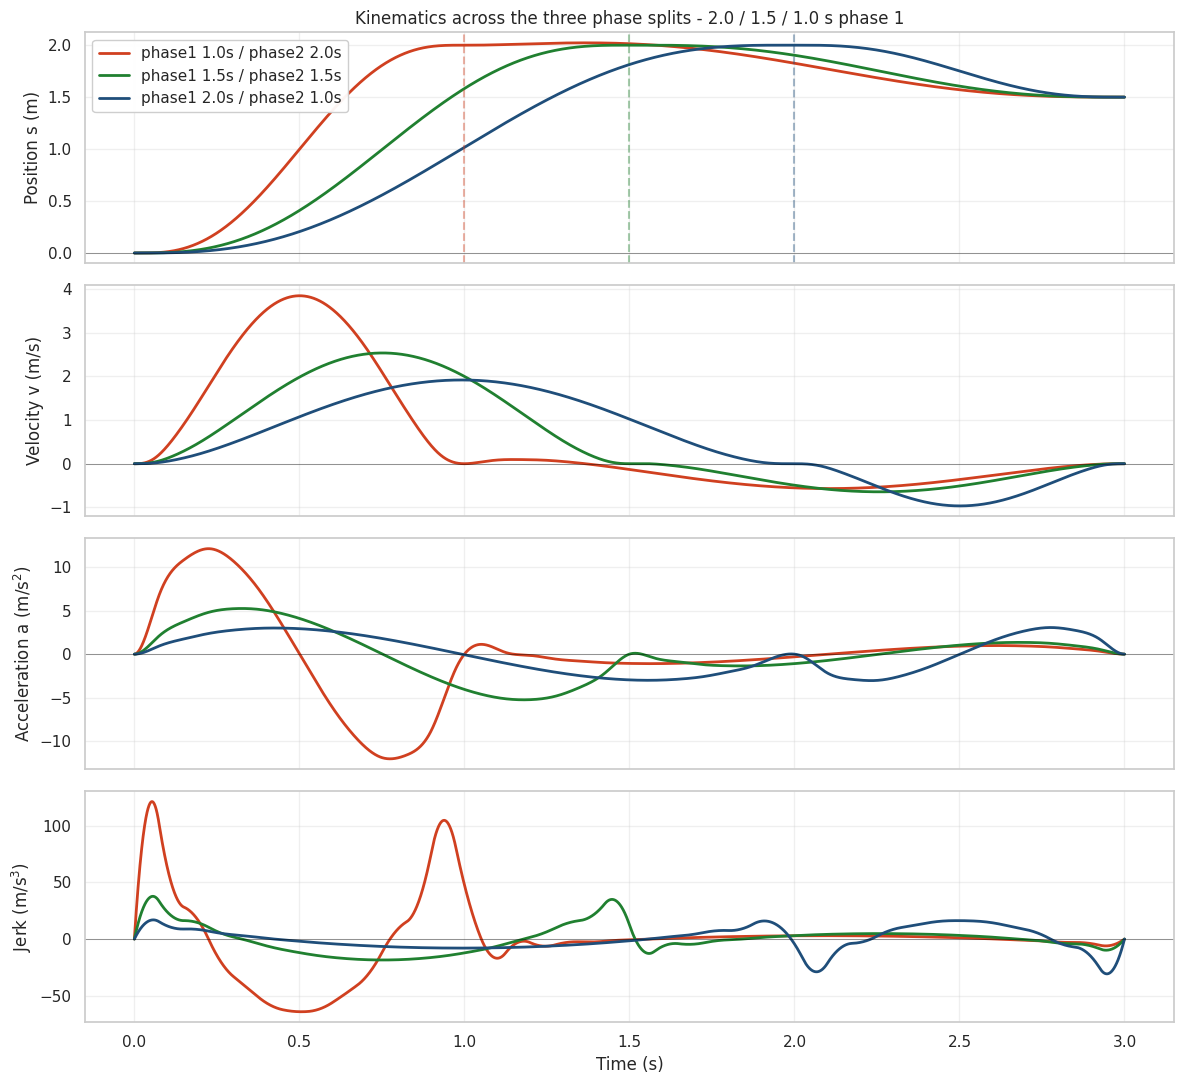

                                   Phase-split comparison                                   
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ phase 1 (s) ┃ phase 2 (s) ┃ peak v (m/s) ┃ peak a (m/s2) ┃ peak a (g) ┃ peak jerk (m/s3) ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         1.0 │         2.0 │         3.84 │         12.16 │       1.24 │            121.4 │
│         1.5 │         1.5 │         2.53 │          5.26 │       0.54 │             37.8 │
│         2.0 │         1.0 │         1.92 │          3.07 │       0.31 │             30.7 │
└─────────────┴─────────────┴──────────────┴───────────────┴────────────┴──────────────────┘

Shorter phase 1 buys phase 2 the room its dense choreography needs - but at a steep cost in phase-1 peak velocity, 
acceleration and jerk.

In [11]:
# Phase-split comparison: t_impact = 1.0, 1.5, 2.0 s
split_times = [1.0, 1.5, 2.0]
split_colors = {1.0: "#d04020", 1.5: "#208030", 2.0: "#1f4e7a"}
split_results = {}
for ti in split_times:
    ak = solve_qp(ti)
    split_results[ti] = kinematics_from_knots(ak)

# Overlaid kinematics curves
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
specs = [("s", "Position s (m)"), ("v", "Velocity v (m/s)"),
         ("a", "Acceleration a (m/s$^2$)"), ("jerk", "Jerk (m/s$^3$)")]
for ti in split_times:
    kin = split_results[ti]
    for ax, (key, _) in zip(axes, specs):
        ax.plot(kin["t"], kin[key], color=split_colors[ti], lw=2,
                label=f"phase1 {ti:.1f}s / phase2 {3-ti:.1f}s")
for ax, (_, ylab) in zip(axes, specs):
    ax.axhline(0, color="black", lw=0.7, alpha=0.4)
    ax.set_ylabel(ylab); ax.grid(True, alpha=0.3)
for ti in split_times:
    axes[0].axvline(ti, color=split_colors[ti], ls="--", alpha=0.4)
axes[0].set_title("Kinematics across the three phase splits - 2.0 / 1.5 / 1.0 s phase 1")
axes[0].legend(loc="upper left", framealpha=0.95)
axes[3].set_xlabel("Time (s)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-phase-split-comparison.png", dpi=140, bbox_inches="tight")
plt.show()

# Comparison table
cmp = Table(title="[bold]Phase-split comparison[/bold]", show_header=True,
            header_style="bold cyan")
for col in ("phase 1 (s)", "phase 2 (s)", "peak v (m/s)", "peak a (m/s2)",
            "peak a (g)", "peak jerk (m/s3)"):
    cmp.add_column(col, justify="right")
for ti in split_times:
    kin = split_results[ti]
    cmp.add_row(f"{ti:.1f}", f"{3-ti:.1f}",
                f"{np.abs(kin['v']).max():.2f}",
                f"{np.abs(kin['a']).max():.2f}",
                f"{np.abs(kin['a']).max()/9.80665:.2f}",
                f"{np.abs(kin['jerk']).max():.1f}")
console.print(cmp)
console.print("[yellow]Shorter phase 1 buys phase 2 the room its dense choreography needs - "
              "but at a steep cost in phase-1 peak velocity, acceleration and jerk.[/yellow]")

## Summary

- One body (Victoria's CoM), one **C4 position trajectory** - cubic-spline acceleration solved as a quadratic program (jerk-squared minimised, linear constraints, exact KKT solve).
- **Three stationary points** - start, impact, end - each with velocity AND acceleration zero.  At the impact the body is at momentary rest; the change of direction is a smooth turning point, not a discontinuity.
- The CoM travels a **2.0 m curved path** (corridor diagonal + body rotation), not a straight line.
- Position, velocity and acceleration are continuous everywhere (verified) - none of notebook 01's infinite-jerk square-wave artefacts.
- **Forces are downstream.**  The total force at the impact will combine an impact-force component (body compressive yield, tabulated above) with an acceleration-force component (Victoria's own push off the door and feet drive).  Their proportion is the `accel_force_fraction` hyperparameter, applied in the force notebook - not here.